### Análisis Exploratorio de Datos (EDA)

#### Reto: ¿Qué canciones debeben estar en nuestras playlist premium y por que?

##### Carga de librerías e inicialización

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carga de dataset limpio
df_spotify_clean = pd.read_csv("../data/processed/spotify_2000_clean.csv")

# Verificación estructura de datos
df_spotify_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   index                 1994 non-null   int64
 1   title                 1994 non-null   str  
 2   artist                1994 non-null   str  
 3   top_genre             1994 non-null   str  
 4   year                  1994 non-null   int64
 5   beats_per_minute_bpm  1994 non-null   int64
 6   energy                1994 non-null   int64
 7   danceability          1994 non-null   int64
 8   loudness_db           1994 non-null   int64
 9   liveness              1994 non-null   int64
 10  valence               1994 non-null   int64
 11  length_duration       1994 non-null   int64
 12  acousticness          1994 non-null   int64
 13  speechiness           1994 non-null   int64
 14  popularity            1994 non-null   int64
dtypes: int64(12), str(3)
memory usage: 233.8 KB


*Verificación del dataset*

In [93]:
# Verificación tamaño dataset y valores faltantes
print("Tamaño de dataset:", df_spotify_clean.shape)
print("\n Número de valores ausentes:")
print(df_spotify_clean.isnull().sum())
print("\n Duplicados:", df_spotify_clean.duplicated().sum())

# Resumen estadístico de las variables acústicas y popularidad
acoustic_features = [
    'beats_per_minute_bpm', 'energy', 'danceability', 'loudness_db', 
    'liveness', 'valence', 'length_duration', 'acousticness', 'speechiness', 'popularity'
]

print("\nResumen estadístico de las variables acústicas y popularidad:")
df_spotify_clean[acoustic_features].describe().round(1)


Tamaño de dataset: (1994, 18)

 Número de valores ausentes:
index                   0
title                   0
artist                  0
top_genre               0
year                    0
beats_per_minute_bpm    0
energy                  0
danceability            0
loudness_db             0
liveness                0
valence                 0
length_duration         0
acousticness            0
speechiness             0
popularity              0
decade                  0
artist_match            0
title_match             0
dtype: int64

 Duplicados: 0

Resumen estadístico de las variables acústicas y popularidad:


,beats_per_minute_bpm,energy,danceability,loudness_db,liveness,valence,length_duration,acousticness,speechiness,popularity
count,1994.0,1994.0,1994.0,1994.0,1994.0,1994.0,1994.0,1994.0,1994.0,1994.0
mean,120.2,59.7,53.2,-9.0,19.0,49.4,262.4,28.9,5.0,59.5
std,28.0,22.2,15.4,3.6,16.7,24.9,93.6,29.0,4.4,14.4
min,37.0,3.0,10.0,-27.0,2.0,3.0,93.0,0.0,2.0,11.0
25%,99.0,42.0,43.0,-11.0,9.0,29.0,212.0,3.0,3.0,49.2
50%,119.0,61.0,53.0,-8.0,12.0,47.0,245.0,18.0,4.0,62.0
75%,136.0,78.0,64.0,-6.0,23.0,69.8,289.0,50.0,5.0,71.0
max,206.0,100.0,96.0,-2.0,99.0,99.0,1412.0,99.0,55.0,100.0


#### ¿Cuáles son las canciones más populares?

*Distribución de popularidad*

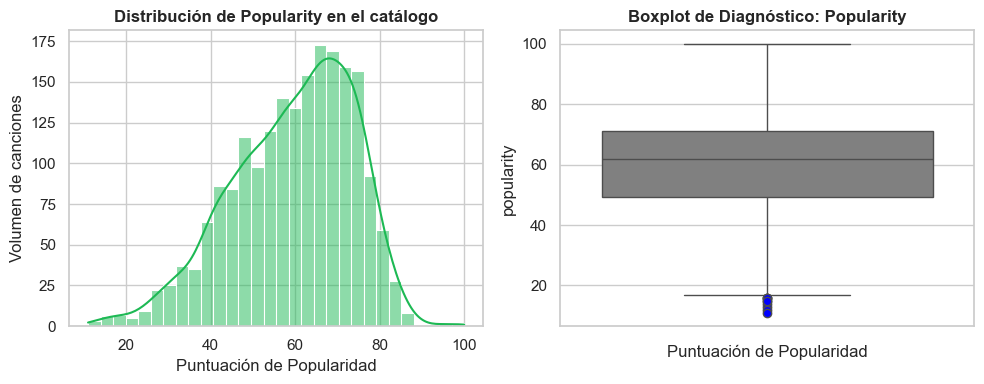

In [40]:
#Histograma de popularidad general del catálogo
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(data=df_spotify_clean['popularity'], kde=True, color='#1DB954', bins=30)
plt.title('Distribución de Popularity en el catálogo', fontsize=12, fontweight='bold') 
plt.xlabel('Puntuación de Popularidad')
plt.ylabel('Volumen de canciones')

# Boxplot popularidad
plt.subplot(1, 2, 2)
sns.boxplot(data=df_spotify_clean['popularity'], color='gray', 
            flierprops={"markerfacecolor":"blue", "marker":"o"})
plt.title('Boxplot de Diagnóstico: Popularity', fontsize=12, fontweight='bold')
plt.xlabel('Puntuación de Popularidad')

plt.tight_layout()
plt.show()

Los valores de popularidad en todo el catálogo tienen como media general 59.4 puntos y una mediana de 62, con algunos outliers de valores bajos.

*Identificación de segmentos de alto y bajo rendimiento*

In [22]:
percentil_75 = df_spotify_clean['popularity'].quantile(0.75) 
# Umbral de bajo rendimiento
percentil_25 = df_spotify_clean['popularity'].quantile(0.25) 

print(f"Corte alto rendimiento (Q3): >= {percentil_75}")
print(f"Corte bajo rendimiento (Q1): <= {percentil_25}\n")


Corte alto rendimiento (Q3): >= 71.0
Corte bajo rendimiento (Q1): <= 49.25



El 25% de las pistas (Q3) tienen un score de popularidad mayor o igual a 71.0 y las pistas con una popularidad menor o igual 49.25 hacen parte del segmento de bajo rendimiento (Q1).

*Segmentación del catálogo por popularidad*

In [ ]:
popularity = df_spotify_clean['popularity']

# Calcula cuartiles
q1 = popularity.quantile(0.25)
q2 = popularity.quantile(0.50)
q3 = popularity.quantile(0.75)

print(
    f"Q1 (25%): {q1:.1f} | "
    f"Q2 (50%): {q2:.1f} | "
    f"Q3 (75%): {q3:.1f}"
)

# Segmentación por popularidad
df_spotify_clean['segment'] = pd.cut(
    df_spotify_clean['popularity'],
    bins=[
        popularity.min()-1,
        q1,
        q2,
        q3,
        popularity.max()
    ],
    labels=[
        '🔴 Bajo',
        '🟡 Medio-Bajo',
        '🟠 Medio-Alto',
        '🟢 Alto'
    ],
    include_lowest=True
)

#Resumen
segment_summary = (
    df_spotify_clean['segment']
    .value_counts()
    .sort_index()
    .reset_index()
)

segment_summary.columns = [
    'Segmento',
    'Canciones'
]

segment_summary['% del catálogo'] = (
    segment_summary['Canciones']
    / len(df_spotify_clean)
    * 100
).round(1)

# Resultado
print("\n SEGMENTACIÓN DEL CATÁLOGO")

print(
    segment_summary.to_string(
        index=False
    )
)

Q1 (25%): 49.2 | Q2 (50%): 62.0 | Q3 (75%): 71.0

 SEGMENTACIÓN DEL CATÁLOGO
    Segmento  Canciones  % del catálogo
      🔴 Bajo        499            25.0
🟡 Medio-Bajo        540            27.1
🟠 Medio-Alto        497            24.9
      🟢 Alto        458            23.0


El catálogo se encuentra distribuido de forma balanceada, el segmento de mayor popularidad equivale al 23% del total con un total de 458 canciones.

#### 

##### ¿Qué géneros vale la pena incluir en las listas premium?


*Identificación de los géneros más populares*

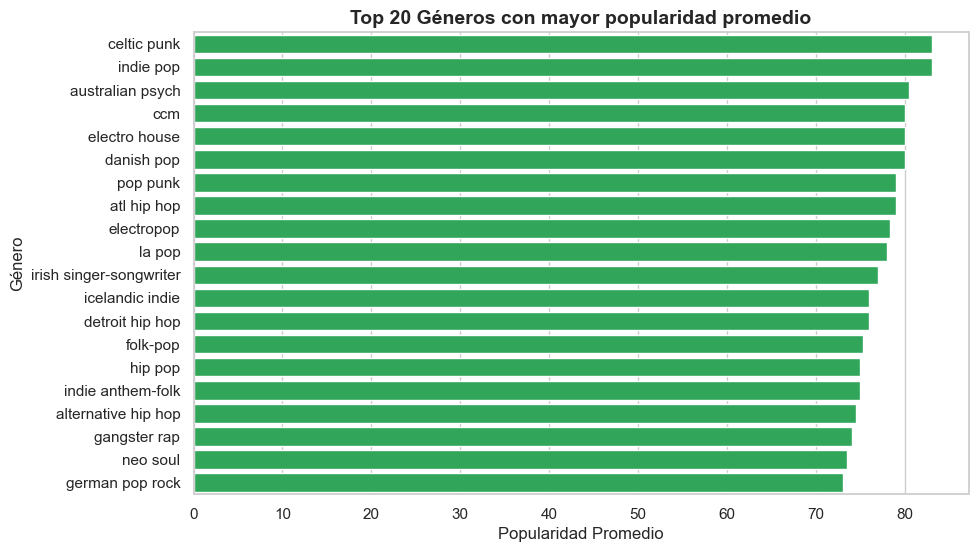

In [ ]:
# Agrupación de géneros por popularidad
genre_popularity = df_spotify_clean.groupby('top_genre').agg(
    total_tracks=('popularity', 'count'),
    popularity_mean=('popularity', 'mean')
).sort_values(by='popularity_mean', ascending=False).head(20)

# Gráfico del top 20 de los géneros más populares del catálogo
plt.figure(figsize=(10, 6))
sns.barplot(data=genre_popularity.reset_index(), x='popularity_mean', y='top_genre', color='#1DB954')
plt.title('Top 20 Géneros con mayor popularidad promedio', fontsize=14, fontweight='bold')
plt.xlabel('Popularidad Promedio')
plt.ylabel('Género')
plt.show()

El top 20 de los géneros con mayor popularidad promedio está liderado por 'celtic pukn' e 'indie pop', el resto del grupo presenta scores entre los 70 y 80 puntos. 

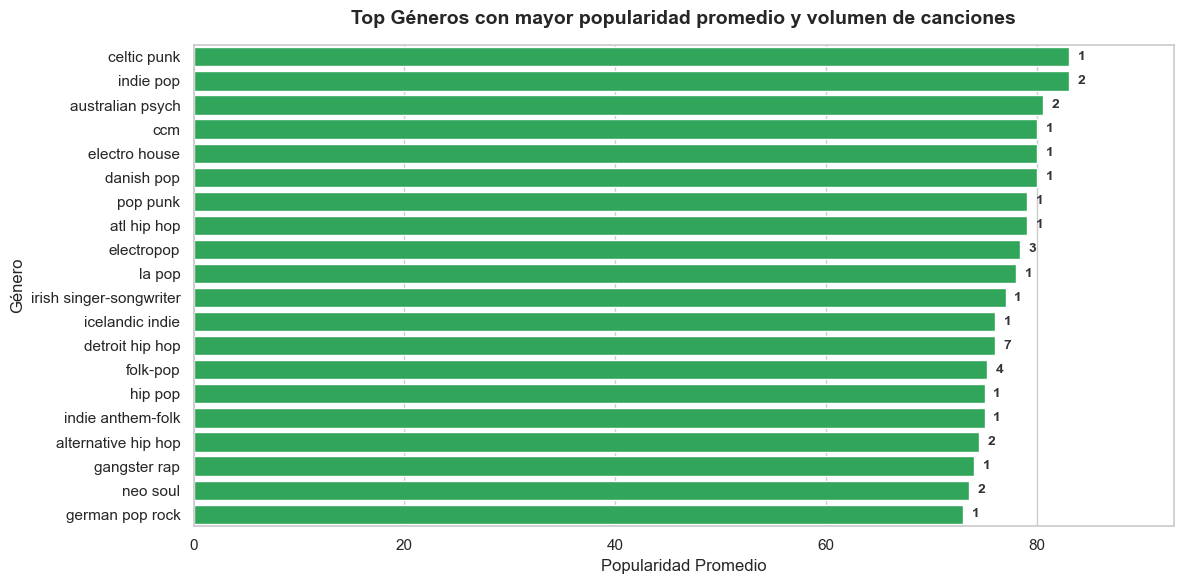

In [36]:
# Incluir el volumen de canciones en cada género del top 20
# Configurar el tamaño y el estilo
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Resetear el índice para que 'top_genre' sea una columna accesible
df_plot = genre_popularity.reset_index()

# Crear el gráfico de barras 
ax = sns.barplot(
    data=df_plot, 
    x='popularity_mean', 
    y='top_genre', 
    color='#1DB954' # Verde Spotify estándar para evitar el bug de las barras en blanco
)

# Dibujar el recuento utilizando la posición de las filas del DataFrame
max_popularidad = df_plot['popularity_mean'].max()

for i, fila in df_plot.iterrows():
    popularidad = fila['popularity_mean']
    conteo_canciones = int(fila['total_tracks'])
    
    # Colocar el texto usando la coordenada del eje Y (que coincide con el índice i)
    ax.text(
        x=popularidad + (max_popularidad * 0.01), # Posición X (justo después del fin de la barra)
        y=i,                                      # Posición Y (el centro de la barra actual)
        s=f'{conteo_canciones}',                # Texto a mostrar (ej: n=15)
        va='center', 
        ha='left', 
        fontsize=10, 
        fontweight='bold',
        color='#333333'
    )

# Personalización del gráfico
ax.set_title('Top Géneros con mayor popularidad promedio y volumen de canciones', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Popularidad Promedio', fontsize=12)
ax.set_ylabel('Género', fontsize=12)

# Ajustar el límite de X para dar espacio al texto
ax.set_xlim(0, max_popularidad * 1.12)

plt.tight_layout()
plt.show()

El volumen de pistas de cada género fluctúa entre 1 y 7.

*Análisis de distribución de volumen por género*


Número de géneros existentes:
149


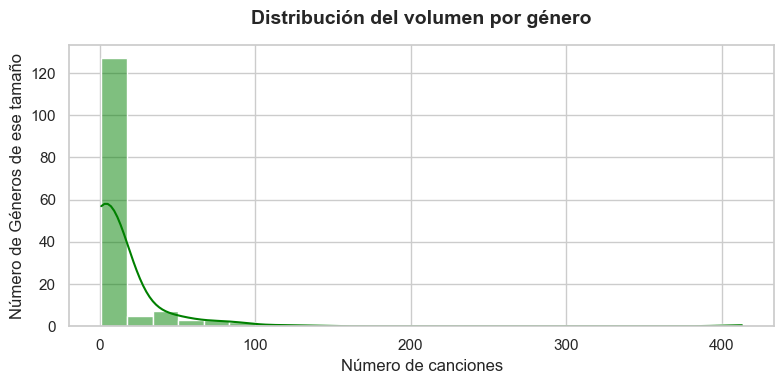

In [37]:
# Número de géneros existentes
print('Número de géneros existentes:')
print(df_spotify_clean['top_genre'].nunique())


# Calcula el volumen de cada género
genre_count = df_spotify_clean['top_genre'].value_counts()

# Grafica el histograma de frecuencias de los tamaños
plt.figure(figsize=(8, 4))

sns.histplot(
    x=genre_count.values, 
    kde=True, 
    color='green' , 
    bins=25
)

plt.title('Distribución del volumen por género', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Número de canciones')
plt.ylabel('Número de Géneros de ese tamaño')

plt.tight_layout()
plt.show()

Esta gráfica de cola larga evidencia que una mínima cantidad de géneros acumulan un gran volúmen de canciones, a su vez, más de 120 géneros de un total de 149 no sobrepasan las 25 canciones.  

**Conclusión**

La asimetría en la distribución del volumen de canciones por género invalida su uso como criterio de segmentación directa. Priorizar los géneros con mayor volumen de registros dejaría por fuera la gran diversidad del catálogo, ignorando piezas de alto rendimiento. Por el contrario, seleccionar géneros basándose únicamente en sus picos de popularidad promedio omitiría la representatividad de su volumen real, comprometiendo la estabilidad de la oferta. Esta contradicción estructural justifica la necesidad de utilizar modelos avanzados que faciliten procesar variables acústicas en paralelo que determinen el sello aústico global de las pistas.

#### Perfil musical

*Análisis de distribución de las variables acústicas*

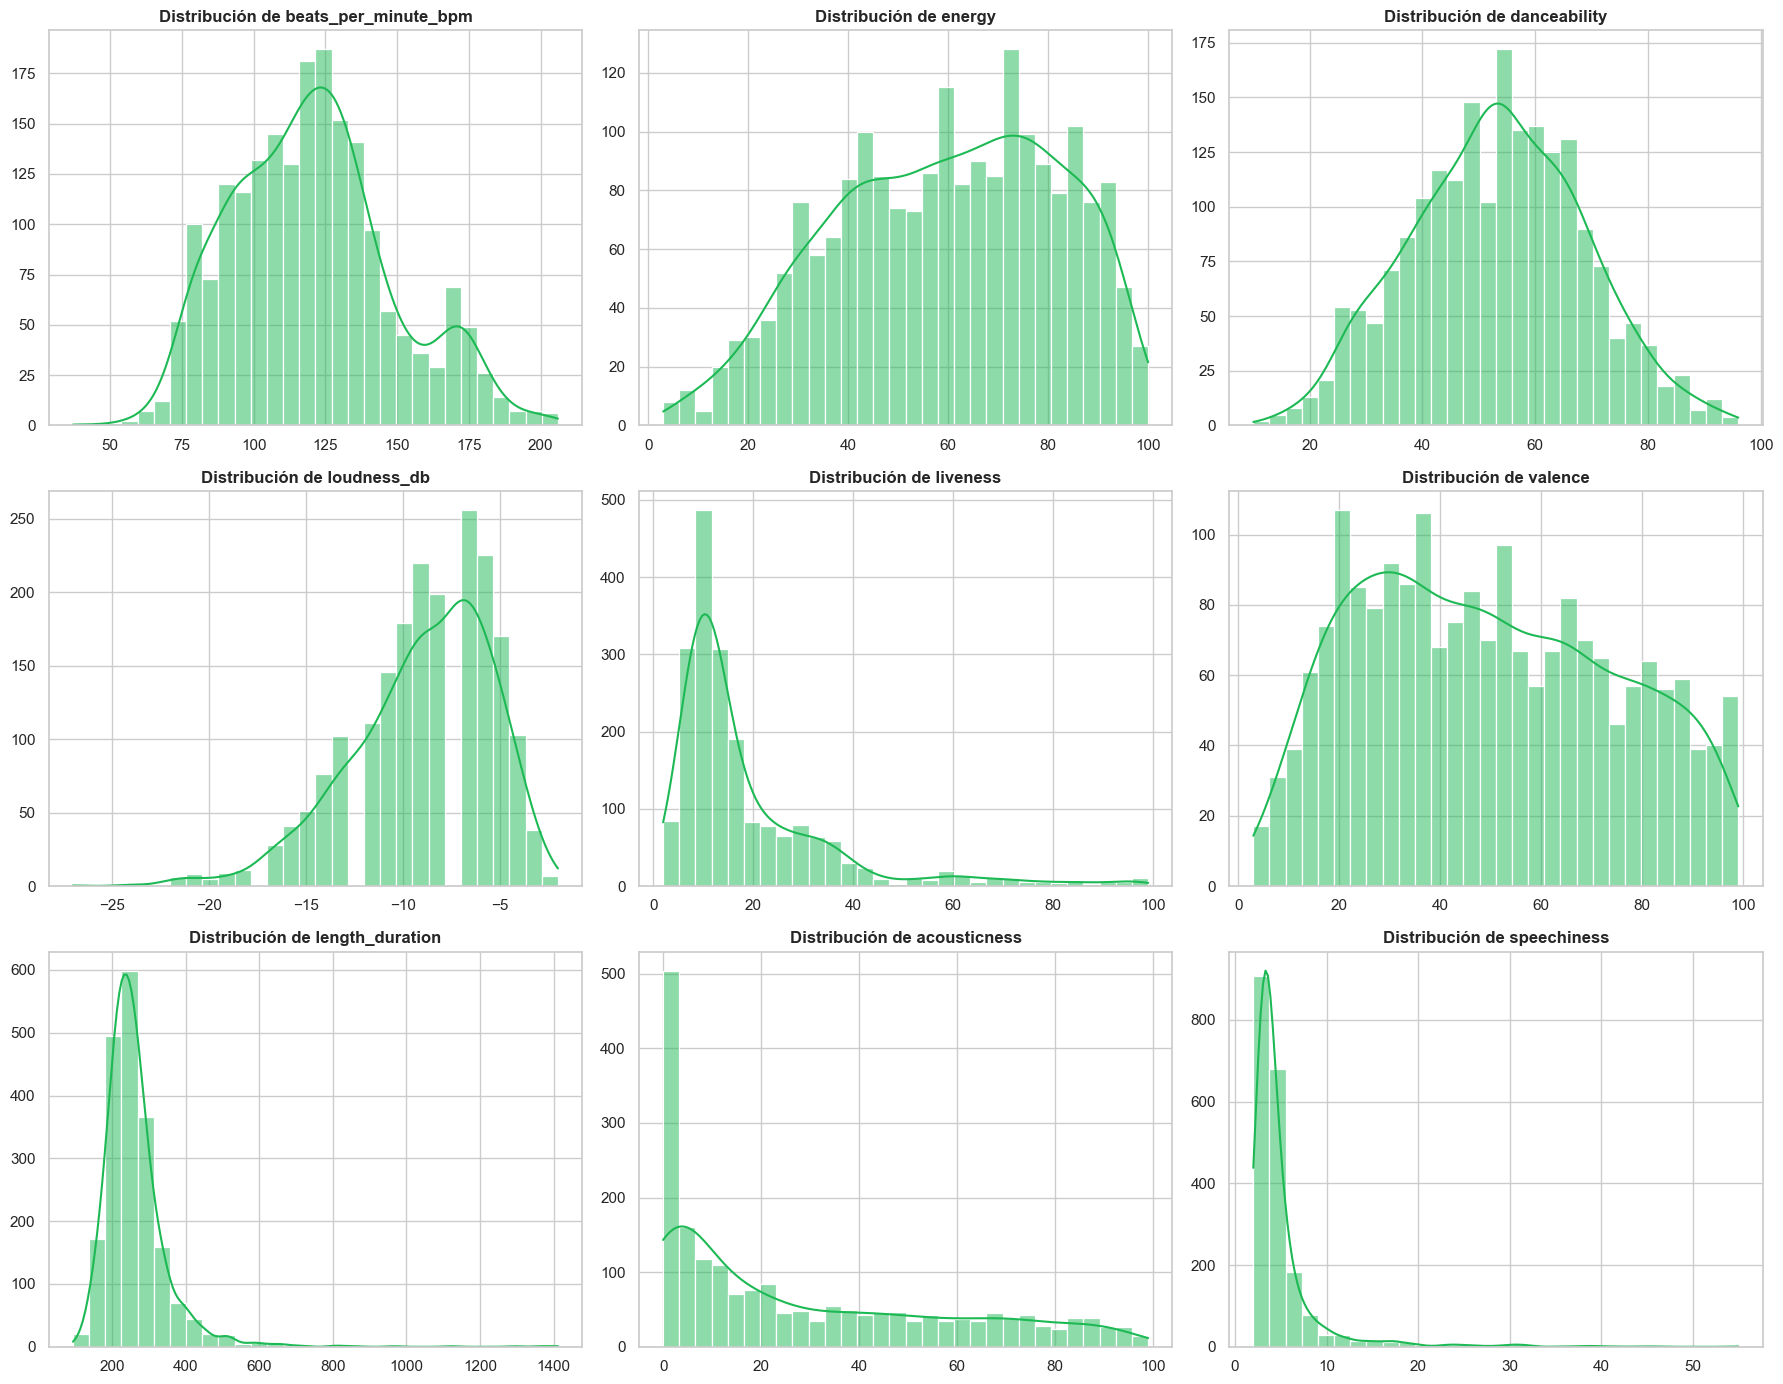

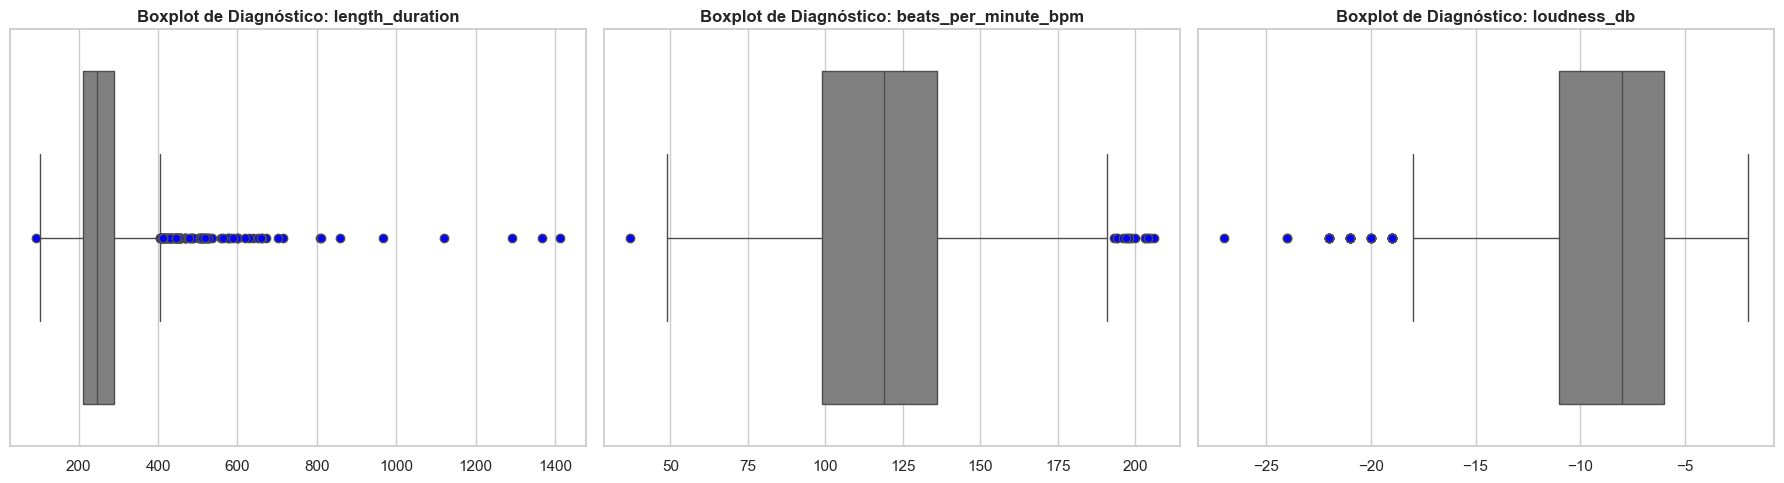

<Figure size 640x480 with 0 Axes>

In [38]:
# Lista de parámetros a evaluar
acoustic_parameters = [
    'beats_per_minute_bpm', 'energy', 'danceability', 'loudness_db', 
    'liveness', 'valence', 'length_duration', 'acousticness', 'speechiness'
]

# Configuración de gráficos de distribución
plt.figure(figsize=(18, 14))

for i, col in enumerate(acoustic_parameters):
    plt.subplot(3, 3, i + 1)
    sns.histplot(data=df_spotify_clean, x=col, kde=True, color='#1DB954', bins=30)
    plt.title(f'Distribución de {col}', fontsize=12, fontweight='bold')
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

# Boxplots para visualizar outliers en variables de escala abierta
plt.figure(figsize=(18, 5))
sub_outliers = ['length_duration', 'beats_per_minute_bpm', 'loudness_db']

for i, col in enumerate(sub_outliers):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(data=df_spotify_clean, x=col, color='gray', 
                flierprops={"markerfacecolor":"blue", "marker":"o"})
    plt.title(f'Boxplot de Diagnóstico: {col}', fontsize=12, fontweight='bold')
    plt.xlabel('')

plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

Las variables beats_per_minute_bpm y danceability tienen distribuciones normales concentradas en 120 BPM y 53.2. energy y valence presentan distribuciones extendidas por todo el catálogo, esta última con sesgo hacia valores bajos. lenght_duration se concentra masivamente entre los 200 y 300 segundos, con cola larga que se extiende hasta los 1400 segundos.
loudness_db esta sesgada a la derecha, la concentración del volumen está entre -10 db y -5 db, acousticness, liveness y speechiness presentan sesgo de valores muy bajos.


length_duration: la mediana de la duración de las canciones es de 245 segundos (4.1 minutos), los diagramas de caja muestran que  posee valores extremadamente atípicos hacia la derecha los cuales superan los 1,000 segundos (16.7 minutos).

beats_per_minute_bpm: a pesar de su distribución normal, la variable presenta outliers por debajo de 50 bpm y por encima de 190 BPM

loudness_db: muestra outliers por debajo de los -18 db y llegan hasta los -27 db.


*Correlación numérica de los atributos acústicos y popularidad*

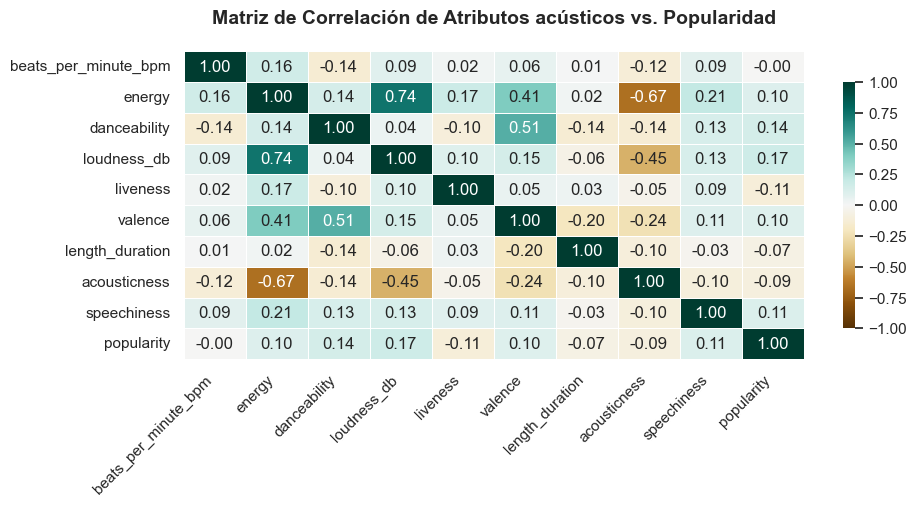

In [39]:
# Definición de variables
columns_corr = acoustic_parameters + ['popularity']

# Matriz de correlación
matriz_corr = df_spotify_clean[columns_corr].corr()

# Mapa de calor
plt.figure(figsize=(10, 4))

sns.heatmap(matriz_corr, cmap='BrBG', vmax=1, vmin=-1, center=0, annot=True, fmt=".2f", linewidths=.5, 
    cbar_kws={"shrink": .8}
)

plt.title('Matriz de Correlación de Atributos acústicos vs. Popularidad', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.show()

La relación entre energy y loudness_db muestra un fuerte coeficiente positivo, en cambio con acousticness la correlación es negativa. Todos los atributos de manera individual muestran correlaciones entre 0.0 y 0.17 frente a la popularidad. 

**Conclusión**

No se observa relación directa de alguna variable con la popularidad. Para los modelos de Machine Learning se eligen las siguientes variables, popularity como determinante del éxito comercial, energy (intensidad), danceability (adecuada para bailar), acousticness (acústica) como filtro de contraste para separar lo orgánico de lo digital y valence (positividad). Se descartan loudness_db por tener una fuerte correlación con energy, speechiness y liveness porque presentan sesgos extremos en su distribución y no aportan información útil para que el algoritmo diferencie una pista de otra. beats_per_minute_bpm y lenght_duration tampoco se tendrán en cuenta por sus escalas abiertas, presencia de outliers y nula contribución a la identificación del aura musical.

## Modelos

### Que generos se escuchan en todas las épocas?

*Popularidad por década*

Resumen de la popularidad promedio por década:


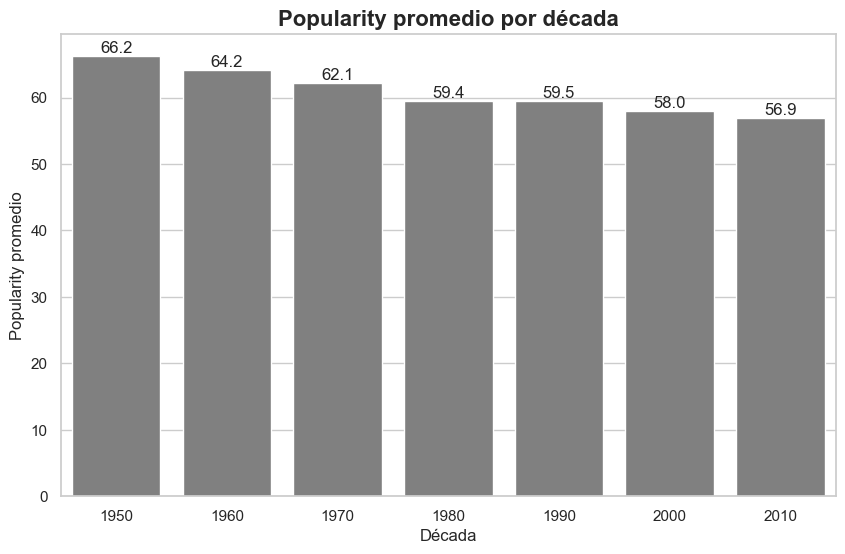

In [82]:
df_spotify_clean["decade"] = (df_spotify_clean["year"] // 10) * 10

decade_summary = (
    df_spotify_clean.groupby("decade")
    .agg(
        total_canciones=("title", "count"),
        popularity_promedio=("popularity", "mean"),
        popularity_mediana=("popularity", "median")
    )
    .reset_index()
    .sort_values("decade")
)

print('Resumen de la popularidad promedio por década:')
decade_summary

# Grafico de popularida por década
plt.figure(figsize=(10, 6))

sns.barplot(
    data=decade_summary,
    x="decade",
    y="popularity_promedio",
    color="gray"
)

plt.title("Popularity promedio por década", fontsize=16, fontweight="bold")
plt.xlabel("Década")
plt.ylabel("Popularity promedio")

for index, row in decade_summary.iterrows():
    plt.text(index, row["popularity_promedio"] + 0.5, f"{row['popularity_promedio']:.1f}", ha="center")

plt.show()

La popularidad promedio sigue un ritmo dececiente a través del tiempo con scores desde 66.2 a 56.9

*Frecuencia de géneros por década*

Matriz de frecuencia de los top 10 géneros más frecuentes por década
decade             1950  1960  1970  1980  1990  2000  2010
top_genre                                                  
album rock            0    57   181    95    37    24    19
adult standards       7    34    40    10    11    16     5
dutch pop             0     0     1     7    10    26    44
alternative rock      0     0     3     7    51    17     8
dance pop             0     0     3    11     8    29    32
dutch indie           0     3     2    10     8    19    33
alternative metal     0     0     0     5    30    26     9
dance rock            0     0     4    23    19     2     4
classic rock          0     6    15    18     4     7     1
dutch cabaret         0     0     2     4    18    20     7
------------------------------------------------------------


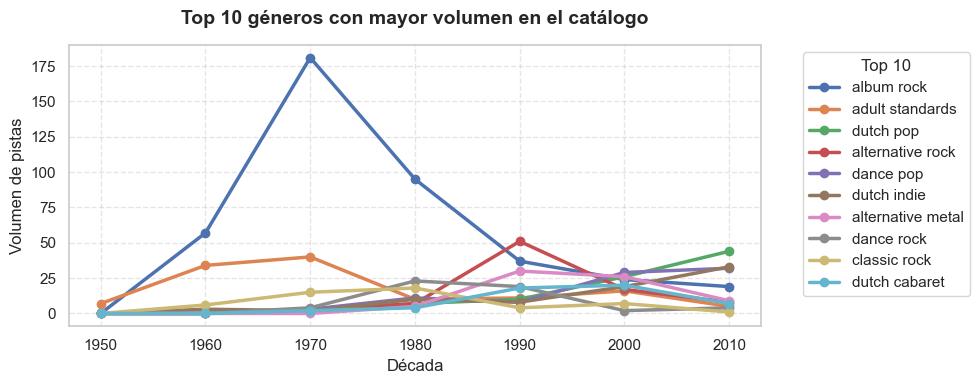

In [ ]:
# Crea una columna en el dataset con la década
df_spotify_clean['decade'] = (df_spotify_clean['year'] // 10) * 10
all_decades = sorted(df_spotify_clean['decade'].unique())

# Visualiza los 10 géneros con mayor volumen total
genre_inter = df_spotify_clean['top_genre'].value_counts().head(10).index

# Filtra usando únicamente este grupo
df_filtered_temporal = df_spotify_clean[df_spotify_clean['top_genre'].isin(genre_inter)]

# Genera la matriz de frecuencia limpia para la visualización
matrix_frequency = pd.crosstab(
    df_filtered_temporal['top_genre'], 
    df_filtered_temporal['decade']
).reindex(genre_inter) 

print("Matriz de frecuencia de los top 10 géneros más frecuentes por década")
print(matrix_frequency)
print("-" * 60)

plt.figure(figsize=(10, 4))

# Bucle a través de cada género validado para graficar su trayectoria histórica
for genre in genre_inter:
    genre_data = df_filtered_temporal[df_filtered_temporal['top_genre'] == genre].groupby('decade').size()
    genre_data = genre_data.reindex(all_decades, fill_value=0)
    
    plt.plot(genre_data.index, genre_data.values, marker='o', linewidth=2.5, label=genre)

plt.title('Top 10 géneros con mayor volumen en el catálogo', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Década', fontsize=12)
plt.ylabel('Volumen de pistas', fontsize=12)
plt.xticks(all_decades)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Top 10")

plt.tight_layout()
plt.show()


In [ ]:
# 
adult_standards_count = (df_spotify_clean['top_genre'] == 'adult standards').sum()
print(f"Pistas totales de 'adult standards': {adult_standards_count}")


Pistas totales de 'adult standards': 123


El único género intergeneracional presente en todas las décadas es adult standards con 123 pistas

#### Exploración dataset grammys

In [96]:
# carga del dataset

df_grammy_clean = pd.read_csv("../data/processed/grammy_awards_clean_final.csv")

# Verificación estructura de datos

print('Columnas de df_spotify_clean:')
print(df_spotify_clean.columns)

print('Columnas de df_grammy_clean:')
print(df_grammy_clean.columns)

Columnas de df_spotify_clean:
Index(['index', 'title', 'artist', 'top_genre', 'year', 'beats_per_minute_bpm',
       'energy', 'danceability', 'loudness_db', 'liveness', 'valence',
       'length_duration', 'acousticness', 'speechiness', 'popularity',
       'decade', 'artist_match', 'title_match'],
      dtype='str')
Columnas de df_grammy_clean:
Index(['year', 'title', 'published_at', 'updated_at', 'category', 'nominee',
       'artist', 'workers', 'img', 'winner'],
      dtype='str')


In [95]:
# Verificación tamaño dataset y valores faltantes
print("Tamaño de dataset:", df_grammy_clean.shape)
print("\n Número de valores ausentes:")
print(df_grammy_clean.isnull().sum())
print("\n Duplicados:", df_grammy_clean.duplicated().sum())


Tamaño de dataset: (4810, 10)

 Número de valores ausentes:
year               0
title              0
published_at       0
updated_at         0
category           0
nominee            6
artist          1840
workers         2190
img             1367
winner             0
dtype: int64

 Duplicados: 0


*Integración de los dataset*

In [ ]:
 # Estandarización de llaves en df_spotify_clean 
df_spotify_clean['match_title'] = df_spotify_clean['title'].astype(str).str.lower().str.strip()
df_spotify_clean['match_artist'] = df_spotify_clean['artist'].astype(str).str.lower().str.strip()

# Estandarización de llaves en df_spotify_clean
# Nota: Usamos 'nominee' para el título de la canción según tu índice de columnas
df_grammy_clean['match_title'] = df_grammy_clean['title'].astype(str).str.lower().str.strip()
df_grammy_clean['match_artist'] = df_grammy_clean['artist'].astype(str).str.lower().str.strip()

# Filtra df_grammy_clean para conservar únicamente a los ganadores reales
df_ganadores_grammy = df_grammy_clean[df_grammy_clean['winner'] == True].copy()

# Eliminar duplicados de premios 
df_ganadores_grammy = df_ganadores_grammy.drop_duplicates(subset=['match_title', 'match_artist'])

# Integración left join para mantener la base de Spotify)
df_catalogo_enriquecido = pd.merge(
    df_spotify_clean,
    df_ganadores_grammy[['match_title', 'match_artist', 'winner', 'category']],
    on=['match_title', 'match_artist'],
    how='left'
)

# Tratamiento de valores nulos post-merge
df_catalogo_enriched = df_catalogo_enriquecido.copy()
df_catalogo_enriched['winner'] = df_catalogo_enriched['winner'].fillna(False).astype(bool)
df_catalogo_enriched['grammy_category'] = df_catalogo_enriched['category'].fillna('Ninguna')

# Elimina columnas temporales 
df_catalogo_enriched = df_catalogo_enriched.drop(columns=['match_title', 'match_artist', 'category'])

print(f"Total de pistas en el catálogo de Spotify: {len(df_catalogo_enriched)}")
total_ganadores = df_catalogo_enriched['winner'].sum()

print(f"Pistas identificadas como GANADORAS DE GRAMMY: {total_ganadores}")


Total de pistas en el catálogo de Spotify: 1994
Pistas identificadas como GANADORAS DE GRAMMY: 0
